In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../MERS/')

## 1. Set up sky models

In [2]:
from fg_model import CNN_PL_sky, GSM_maps

# Set up the frequency list: [50, 200] MHz
freq_list = np.linspace(50., 200., 101)
Nfreq = len(freq_list)

# Set up the Nside for full map analysis
Nside = 128

# 1. CNN-PL sky model
CNN_sky, pivot_specidx_map = CNN_PL_sky(freq_list, beam_transfer=None, nside=Nside, return_spec_index=True)

# 2. GSM sky model
GSM_sky = GSM_maps(freq_list, nside=Nside, beam_transfer=None) 

## 2. Fitting sky models

In [3]:
from SEDfitting import fit_fg_cube

### 2.1 CNN-PL (Fixed pivot)

In [4]:
max_order = 3
sky_model = CNN_sky

CNNpl_coeffs_3, CNNpl_loss_3, CNNpl_resi_3 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

In [5]:
max_order = 4
sky_model = CNN_sky

CNNpl_coeffs_4, CNNpl_loss_4, CNNpl_resi_4 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

In [6]:
max_order = 5
sky_model = CNN_sky

CNNpl_coeffs_5, CNNpl_loss_5, CNNpl_resi_5 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

In [7]:
max_order = 6
sky_model = CNN_sky

CNNpl_coeffs_6, CNNpl_loss_6, CNNpl_resi_6 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

### 2.2 GSM (Fixed pivot)


In [8]:
max_order = 3
sky_model = GSM_sky

GSM_coeffs_3, GSM_loss_3, GSM_resi_3 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

max_order = 4
sky_model = GSM_sky

GSM_coeffs_4, GSM_loss_4, GSM_resi_4 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

max_order = 5
sky_model = GSM_sky

GSM_coeffs_5, GSM_loss_5, GSM_resi_5 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

max_order = 6
sky_model = GSM_sky

GSM_coeffs_6, GSM_loss_6, GSM_resi_6 = fit_fg_cube(
    sky_model, 
    pivot_specidx_map, 
    freq_list, 
    nu_ref=None, 
    max_order=max_order, 
    adaptive_pivot=False, 
    remove_1st_moment=False,
    BCSVD=None, 
    BCF=None
)

## 3. Visualisation

### 3.1 Loss maps using different orders of moments

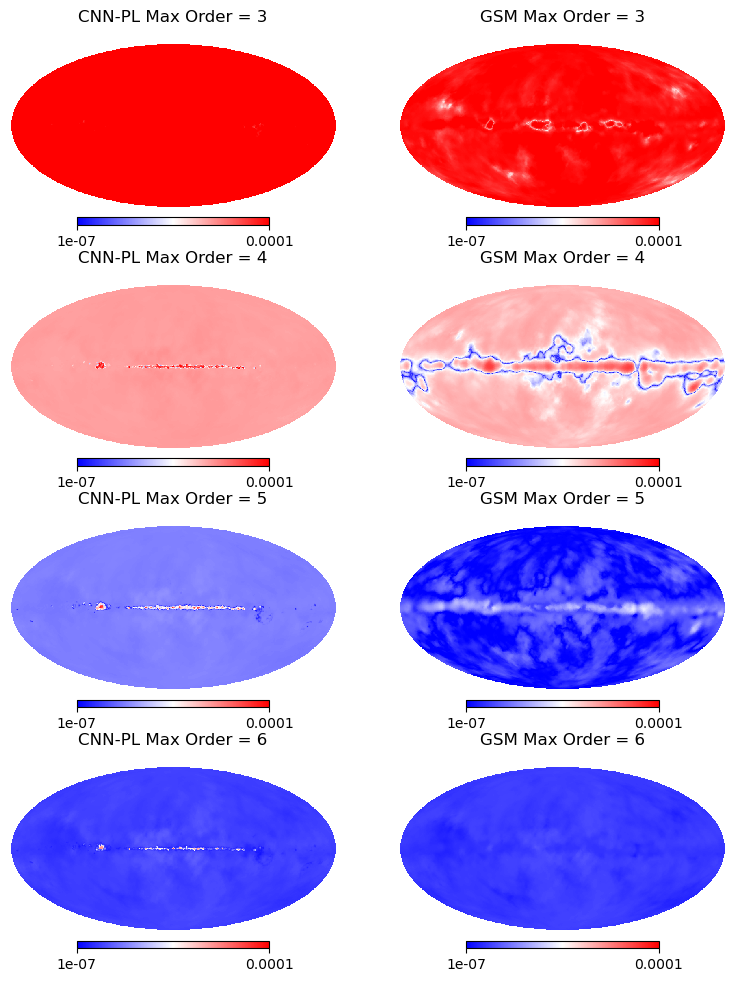

In [13]:

# Generate a figure with 8 subplots, with the layout as 4 rows and 2 columns.
# The first row are healmaps of CNNpl_loss_3 and GSM_loss_3, with the same colorbar.
# The second row are healmaps of CNNpl_loss_4 and GSM_loss_4, with the same colorbar.
# The third row are healmaps of CNNpl_loss_5 and GSM_loss_5, with the same colorbar.
# The fourth row are healmaps of CNNpl_loss_6 and GSM_loss_6, with the same colorbar.

def plot_loss_comparison(savepath=None):
    plt.figure(figsize=(10, 12))
    
    maps = [
        (CNNpl_loss_3, GSM_loss_3, 'Max Order = 3'),
        (CNNpl_loss_4, GSM_loss_4, 'Max Order = 4'),
        (CNNpl_loss_5, GSM_loss_5, 'Max Order = 5'),
        (CNNpl_loss_6, GSM_loss_6, 'Max Order = 6')
    ]

    titles = ['CNN-PL', 'GSM', '']

    gs = plt.GridSpec(4, 2, width_ratios=[1, 1], height_ratios=[1, 1, 1, 1], wspace=0.01)

    for row in range(4):
        map1, map2, label = maps[row]
        
        # vmin = min(np.nanpercentile(map1, 1), np.nanpercentile(map2, 1))
        # vmax = max(np.nanpercentile(map1, 99), np.nanpercentile(map2, 99))
        vmin = 1e-7
        vmax = 1e-4
        
        cbar='bwr'
        ax1 = plt.subplot(gs[row, 0], projection='mollweide')
        im1 = hp.mollview(map1, title='', hold=True, 
                          min=vmin, max=vmax, 
                          norm='log',
                          cmap=cbar)
        plt.text(0.5, 1.1, f'{titles[0]} {label}', 
                ha='center', va='bottom', transform=ax1.transAxes, fontsize=12)
        
        ax2 = plt.subplot(gs[row, 1], projection='mollweide')
        im2 = hp.mollview(map2, title='', hold=True, 
                          min=vmin, max=vmax, 
                          norm='log',
                          cmap=cbar)
        plt.text(0.5, 1.1, f'{titles[1]} {label}', 
                ha='center', va='bottom', transform=ax2.transAxes, fontsize=12)
        
        # cax = plt.subplot(gs[row, 2])
        # plt.colorbar(im1['cmap'], cax=cax).set_label('Loss Value', fontsize=10)
    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    #plt.suptitle('Spectral Moment Fitting Error Comparison', y=0.93, fontsize=14)
    plt.show()

plot_loss_comparison(savepath='figures/diffuse_sky_loss.pdf')

### 3.2 Moment coefficient maps of the two models (fitted with maximum order 6)

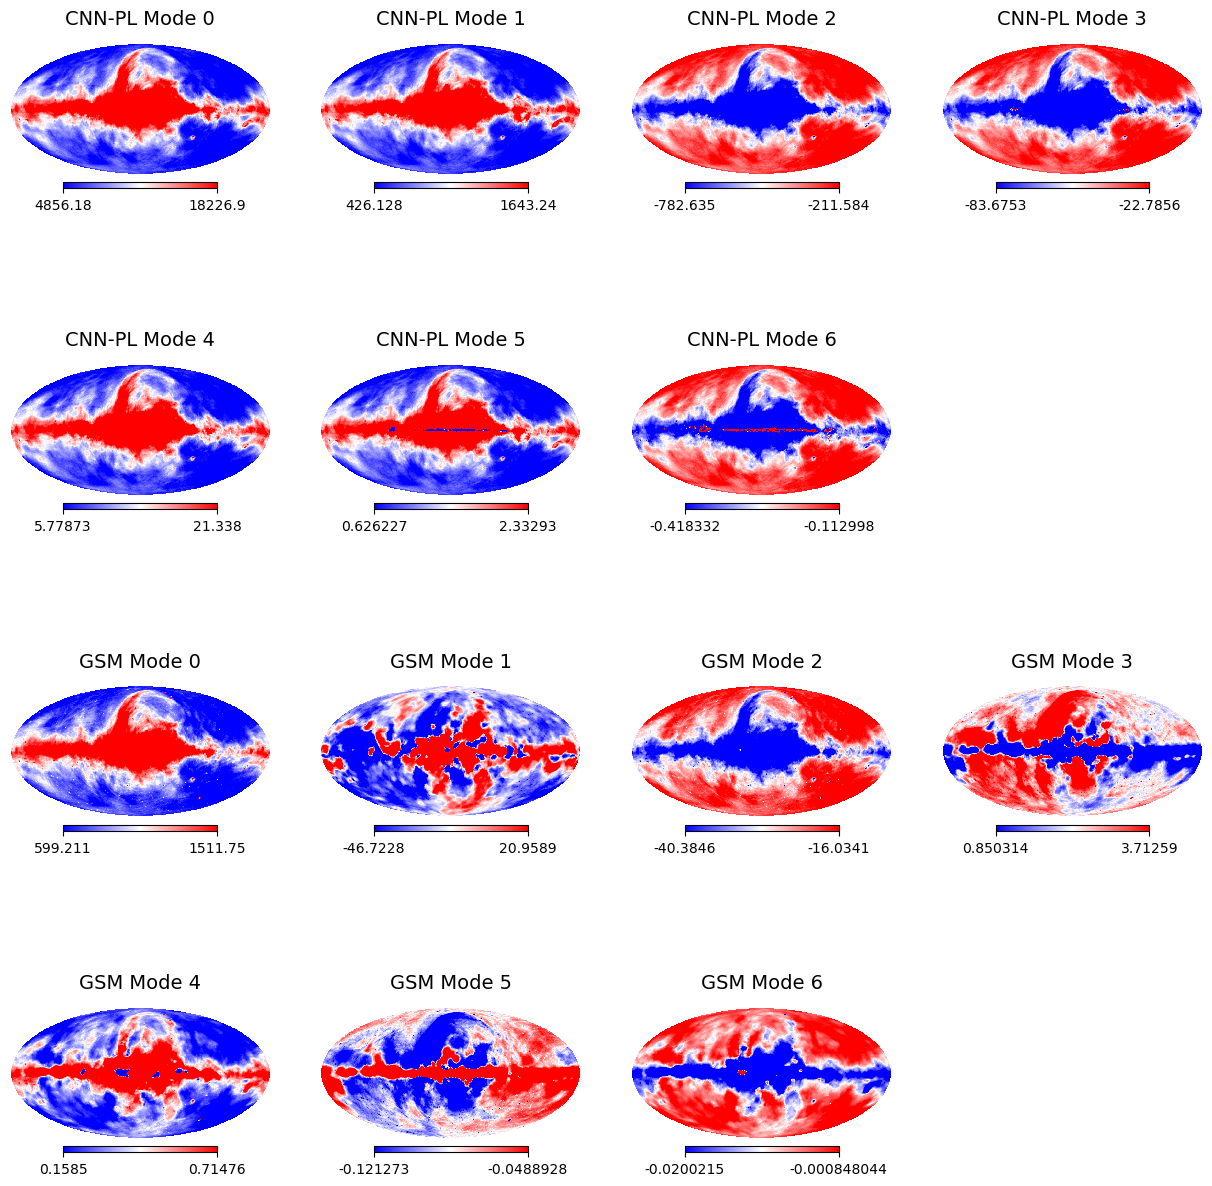

In [15]:

def plot_moment_maps(savepath=None):
    plt.figure(figsize=(16, 16))
    

    titles = [['CNN-PL']*7, ['GSM']*7]

    gs = plt.GridSpec(4, 4, width_ratios=[1, 1, 1, 1], height_ratios=[1,1,1,1], wspace=0.01)

    # Get the 16 and 84 percentiles
    # vmin = np.percentile(Mel_moment_coeffs_maps_6_fixed, 16)
    # vmax = np.percentile(Mel_moment_coeffs_maps_6_fixed, 84)

    vmin_ls = []
    vmax_ls = []

    for i in range(7):
        vmin_Mel = np.percentile(CNNpl_coeffs_6[:,i], 16)
        vmax_Mel = np.percentile(CNNpl_coeffs_6[:,i], 84)
        vmin_GSM = np.percentile(GSM_coeffs_6[:,i], 16)
        vmax_GSM = np.percentile(GSM_coeffs_6[:,i], 84)
        vmin_ls.append(min(vmin_Mel, vmin_GSM))
        vmax_ls.append(max(vmax_Mel, vmax_GSM))
        

    for row in range(2):
        for col in range(4):
            ind=row*4+col

            if ind>=7:
                break

            map=CNNpl_coeffs_6[:,ind]
            # vmin = vmin_ls[ind]
            # vmax = vmax_ls[ind]
            vmin = np.percentile(map, 16)
            vmax = np.percentile(map, 84)
        
            if ind==0:
                # not using diverging colormap
                cbar='bwr'
            else:
                # using diverging colormap
                cbar='bwr'
            ax1 = plt.subplot(gs[row, col], projection='mollweide')
            im1 = hp.mollview(map, title='', hold=True, 
                            min=vmin, max=vmax, 
                            #norm='log',
                            cmap=cbar)
            plt.text(0.5, 1.1, f'{titles[0][ind]} Mode {ind}', 
                    ha='center', va='bottom', transform=ax1.transAxes, fontsize=14)

    for row in range(2):
        for col in range(4):
            ind=row*4+col

            if ind>=7:
                break
            map=GSM_coeffs_6[:,ind]

            vmin = np.percentile(map, 16)
            vmax = np.percentile(map, 84)
            # vmin = vmin_ls[ind]
            # vmax = vmax_ls[ind]
        
            if ind==0:
                # not using diverging colormap
                cbar='bwr'
            else:
                # using diverging colormap
                cbar='bwr'
            ax1 = plt.subplot(gs[row+2, col], projection='mollweide')
            im1 = hp.mollview(map, title='', hold=True, 
                            min=vmin, max=vmax, 
                            #norm='log',
                            cmap=cbar)
            plt.text(0.5, 1.1, f'{titles[1][ind]} Mode {ind}', 
                    ha='center', va='bottom', transform=ax1.transAxes, fontsize=14)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    #plt.suptitle('Spectral Moment Fitting Error Comparison', y=0.93, fontsize=14)
    plt.show()

plot_moment_maps(savepath='figures/moment_maps_CNNPL_GSM.pdf')